# StyleTTS2 Fine-tuning — Asante-Twi

End-to-end pipeline:
1. Install packages & clone StyleTTS2
2. Mount Google Drive (checkpoints + logs saved there every 2 epochs)
3. Load & prepare the HF Twi dataset (filter by duration, convert wavs)
4. Build `train_list.txt` / `val_list.txt` with **twi-g2p** phonemes
5. Patch `models.py`, update config, and launch training
6. Inference / test the fine-tuned model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Install packages & download models

In [ ]:
%%shell
git clone https://github.com/yl4579/StyleTTS2.git
cd StyleTTS2
pip install SoundFile torchaudio munch torch pydub pyyaml librosa nltk matplotlib \
    accelerate transformers phonemizer einops einops-exts tqdm typing-extensions \
    git+https://github.com/resemble-ai/monotonic_align.git
pip install datasets soundfile
sudo apt-get install -y espeak-ng
# twi-g2p phonemiser
pip install git+https://github.com/GhanaNLP/twi-g2p.git#egg=twi-g2p[all]
# download pre-trained LibriTTS weights
git-lfs clone https://huggingface.co/yl4579/StyleTTS2-LibriTTS
mv StyleTTS2-LibriTTS/Models .

Cloning into 'StyleTTS2'...
remote: Enumerating objects: 372, done.
remote: Total 372 (delta 0), reused 0 (delta 0), pack-reused 372 (from 1)
Receiving objects: 100% (372/372), 133.98 MiB | 36.56 MiB/s, done.
Resolving deltas: 100% (198/198), done.
Updating files: 100% (48/48), done.
  Cloning https://github.com/resemble-ai/monotonic_align.git to /tmp/pip-req-build-1ukdk9ht
  Running command git clone --filter=blob:none --quiet https://github.com/resemble-ai/monotonic_align.git /tmp/pip-req-build-1ukdk9ht
  Resolved https://github.com/resemble-ai/monotonic_align.git to commit c6e5e6cb19882164027eb6e35118e841eed9298e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
espeak-ng is already the newest version (1.50+dfsg-10ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
DEPRECATION: gi

## 2. Google Drive — checkpoint output folder

Set `GDRIVE_OUTPUT_DIR` to the folder where you want checkpoints and training logs saved.
**Only `.pth` checkpoints and `train_log.txt` are synced — raw wavs and data caches stay local.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── ✏️  Edit this path to your desired Google Drive folder ───────────────────
GDRIVE_OUTPUT_DIR = "/content/drive/MyDrive/StyleTTS2_Twi/checkpoints"
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(GDRIVE_OUTPUT_DIR, exist_ok=True)
print(f"Drive output dir: {GDRIVE_OUTPUT_DIR}")

Mounted at /content/drive
Drive output dir: /content/drive/MyDrive/StyleTTS2_Twi/checkpoints


## 3. Load & prepare the Hugging Face Twi dataset

In [ ]:
%cd StyleTTS2
!mkdir -p Data/wavs Data/wavs_converted

import os, re, random, subprocess, glob
import numpy as np
import librosa
import soundfile as sf
from datasets import load_dataset

# ── Configuration ────────────────────────────────────────────────────────────
HF_DATASET_NAME  = "ghananlpcommunity/asante-twi-bible-speech-text"
HF_SPLIT         = "train"
AUDIO_COLUMN     = "audio"
TEXT_COLUMN      = "text"
TARGET_SR        = 24000
MIN_DURATION_SEC = 3.0
MAX_DURATION_SEC = 8.0
MAX_SAMPLES      = 1000
WAV_DIR          = "Data/wavs"
WAV_CONVERTED    = "Data/wavs_converted"
TRAIN_LIST       = "Data/train_list.txt"
VAL_LIST         = "Data/val_list.txt"
VAL_SPLIT        = 0.05
# ─────────────────────────────────────────────────────────────────────────────

def sanitize(text: str) -> str:
    return re.sub(r'[|\n\r]', ' ', text).strip()

print(f"Loading dataset: {HF_DATASET_NAME} …")
dataset = load_dataset(HF_DATASET_NAME, split=HF_SPLIT)
print(f"  Total rows: {len(dataset)}")

# ── Filter, resample, write wavs ─────────────────────────────────────────────
kept_entries = []  # (wav_filename, transcript) — filename only, no path prefix
skipped = 0

for idx, sample in enumerate(dataset):
    if len(kept_entries) >= MAX_SAMPLES:
        break
    audio_data = sample[AUDIO_COLUMN]
    waveform   = np.array(audio_data["array"], dtype=np.float32)
    sr_orig    = audio_data["sampling_rate"]
    duration   = len(waveform) / sr_orig
    if duration < MIN_DURATION_SEC or duration > MAX_DURATION_SEC:
        skipped += 1
        continue
    if sr_orig != TARGET_SR:
        waveform = librosa.resample(waveform, orig_sr=sr_orig, target_sr=TARGET_SR)
    wav_filename = f"sample_{idx:06d}.wav"
    sf.write(os.path.join(WAV_DIR, wav_filename), waveform, TARGET_SR)
    transcript = sanitize(sample[TEXT_COLUMN])
    kept_entries.append((wav_filename, transcript))

print(f"Samples kept: {len(kept_entries)} | skipped (duration): {skipped}")

# ── Convert to mono s16 24 kHz via ffmpeg ────────────────────────────────────
print("Converting wavs …")
for f in glob.glob(f"{WAV_DIR}/*.wav"):
    out = f.replace(WAV_DIR + "/", WAV_CONVERTED + "/")
    subprocess.run(
        ["ffmpeg", "-y", "-i", f, "-ac", "1", "-ar", "24000", "-sample_fmt", "s16", out],
        stderr=subprocess.DEVNULL
    )
print("Done converting.")

/content/StyleTTS2
Loading dataset: ghananlpcommunity/asante-twi-bible-speech-text …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/513 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

...

data/test-00004-of-00005.parquet:   0%|          | 0.00/393M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/34164 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3796 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/42 [00:00<?, ?it/s]

  Total rows: 34164
Samples kept: 1000 | skipped (duration): 1317
Converting wavs …
Done converting.


## 4. Build train/val lists with twi-g2p phonemes

Uses [twi-g2p](https://github.com/GhanaNLP/twi-g2p) to generate VITS-compatible space-separated phoneme sequences for each transcript.

In [ ]:
from twi_g2p import TwiG2P

# Using 'vits' format: space-separated IPA tokens, e.g.  "p a p a"
# Change to 'piper' for {p a p a} format if you prefer Piper-style
G2P_FORMAT = "vits"
g2p = TwiG2P(output_format=G2P_FORMAT)

random.seed(42)
random.shuffle(kept_entries)

n_val   = max(1, int(len(kept_entries) * VAL_SPLIT))
val_set = kept_entries[:n_val]
trn_set = kept_entries[n_val:]

def write_list(path, entries):
    """Write  filename.wav|transcript|speaker_id  (one line per sample)."""
    with open(path, "w", encoding="utf-8") as f:
        for wav_filename, transcript in entries:
            try:
                phonemes = g2p.convert(transcript)
            except Exception:
                phonemes = transcript  # fall back to raw text on error
            f.write(f"{wav_filename}|{phonemes}|0\n")

write_list(TRAIN_LIST, trn_set)
write_list(VAL_LIST,   val_set)

print(f"Train: {len(trn_set)} samples → {TRAIN_LIST}")
print(f"Val  : {len(val_set)} samples → {VAL_LIST}")
print("\nFirst 3 train lines:")
with open(TRAIN_LIST) as f:
    for _, line in zip(range(3), f):
        print(" ", repr(line.strip()))

Train: 950 samples → Data/train_list.txt
Val  : 50 samples → Data/val_list.txt

First 3 train lines:
  'sample_001026.wav|n a e h o n a n a j o̘ r a m d a n a j u̘ d a h e̘ n e̘ a h a s i̘ a a s i̘ a n e̘ a b a s e o r e̘ b e hʷ e j o̘ r a m|0'
  'sample_002248.wav|n a s r a a a r o̘ n n e̘ n e̘ m̩ m a n o̘ n̩ g o̘ j e w o n k r o̘ ŋk r o̘ n n a w o n̩ n i̘ m e̘ a s o f o̘ o|0'
  'sample_000039.wav|n a o r e̘ k a s a a n o̘ m u̘ n u̘ ŋk u̘ m b a b e k a t a a w o n s o̘ n a w o r e̘ k o m u̘ n u̘ ŋk u̘ m n o̘ m u̘ n o̘ w o s u̘ r o̘ e̘|0'


## 5. Configure fine-tuning

- Points the config at the converted wavs
- Sets `save_freq = 2` so checkpoints are written every 2 epochs
- After each checkpoint, **only the `.pth` files and the log are copied to Google Drive** (no wavs/caches)

In [ ]:
import yaml, re as _re

config_path = "Configs/config_ft.yml"

# ── 1. Update YAML config ─────────────────────────────────────────────────────
with open(config_path) as f:
    cfg = yaml.safe_load(f)

cfg['data_params']['root_path']  = WAV_CONVERTED
cfg['data_params']['train_data'] = TRAIN_LIST
cfg['data_params']['val_data']   = VAL_LIST
cfg['batch_size']                = 2    # reduce if OOM
cfg['max_len']                   = 100  # reduce if OOM
cfg['save_freq']                 = 2    # save checkpoint every 2 epochs
cfg['loss_params']['joint_epoch']= 110  # skip SLM adversarial stage (~40 GB VRAM)

with open(config_path, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

print("Config updated.")
print(f"  root_path  : {cfg['data_params']['root_path']}")
print(f"  train_data : {cfg['data_params']['train_data']}")
print(f"  val_data   : {cfg['data_params']['val_data']}")
print(f"  save_freq  : {cfg['save_freq']} epochs")

# ── 2. Patch models.py — add weights_only=False to torch.load calls ───────────
filepath = "/content/StyleTTS2/models.py"
with open(filepath, "r") as f:
    content = f.read()
patched = _re.sub(
    r"torch\.load\(([^)]+),\s*map_location='cpu'\)",
    r"torch.load(\1, map_location='cpu', weights_only=False)",
    content
)
with open(filepath, "w") as f:
    f.write(patched)
print("models.py patched (weights_only=False).")

# ── 3. Download OOD texts ─────────────────────────────────────────────────────
!wget -q -P Data/ https://raw.githubusercontent.com/yl4579/StyleTTS2/main/Data/OOD_texts.txt
print("OOD_texts.txt ready.")

Config updated.
  root_path  : Data/wavs_converted
  train_data : Data/train_list.txt
  val_data   : Data/val_list.txt
  save_freq  : 2 epochs
models.py patched (weights_only=False).
OOD_texts.txt ready.


## 6. Start fine-tuning

After training completes (or is interrupted), checkpoints every 2 epochs are synced to Google Drive — **wavs and data cache are excluded**.

In [ ]:
import subprocess, shutil, os, glob, threading, time

LOCAL_CKPT_DIR = "Models/LJSpeech"

def sync_to_drive(local_dir, drive_dir, interval_sec=60):
    """Background thread: copy *.pth and *log*.txt to Drive every `interval_sec`.
    Never copies wavs, wavs_converted, or HF dataset cache."""
    while True:
        time.sleep(interval_sec)
        os.makedirs(drive_dir, exist_ok=True)
        for pattern in ["*.pth", "*log*.txt", "*.yml"]:
            for src in glob.glob(os.path.join(local_dir, pattern)):
                dst = os.path.join(drive_dir, os.path.basename(src))
                try:
                    shutil.copy2(src, dst)
                except Exception as e:
                    print(f"[sync] Warning: {e}")
        print(f"[sync] Synced {local_dir} → {drive_dir}")

# Start background sync (every 60 s — checkpoints land only every 2 epochs
# so this is just a heartbeat to catch them promptly)
sync_thread = threading.Thread(
    target=sync_to_drive,
    args=(LOCAL_CKPT_DIR, GDRIVE_OUTPUT_DIR, 60),
    daemon=True
)
sync_thread.start()
print("Background Drive sync started.")

# ── Run training ──────────────────────────────────────────────────────────────
!python train_finetune.py --config_path ./Configs/config_ft.yml

# ── Final sync after training ends ───────────────────────────────────────────
import shutil, glob, os
os.makedirs(GDRIVE_OUTPUT_DIR, exist_ok=True)
for pattern in ["*.pth", "*log*.txt", "*.yml"]:
    for src in glob.glob(os.path.join(LOCAL_CKPT_DIR, pattern)):
        shutil.copy2(src, os.path.join(GDRIVE_OUTPUT_DIR, os.path.basename(src)))
print(f"Final sync complete → {GDRIVE_OUTPUT_DIR}")

Streaming output truncated to the last 5000 lines.
n a w o b u̘ a a n o̘ s e j o̘ h a n e̘ s u̘ b o̘ n i̘ n a e̘ b i̘ n o̘ m s e̘ e̘ l i̘ a n a e̘ b i̘ n o̘ m n̩ s o̘ s e̘ a d i̘ j i̘ f o̘ o n o̘ m u̘ b a a k o̘
n a w o b u̘ a a n o̘ s e j o̘ h a n e̘ s u̘ b o̘ n i̘ n a e̘ b i̘ n o̘ m s e̘ e̘ l i̘ a n a e̘ b i̘ n o̘ m n̩ s o̘ s e̘ a d i̘ j i̘ f o̘ o n o̘ m u̘ b a a k o̘
n a o m a n n o̘ hʲ i̘ r a a m̩ m a r i̘ m a a w o j i̘ i̘ w o n j a m s e w o r e̘ b e t e̘ n a j e̘ r u̘ s a l e̘ m n o̘ nʲ i̘ n a a
n a o m a n n o̘ hʲ i̘ r a a m̩ m a r i̘ m a a w o j i̘ i̘ w o n j a m s e w o r e̘ b e t e̘ n a j e̘ r u̘ s a l e̘ m n o̘ nʲ i̘ n a a
n a o m a n n o̘ hʲ i̘ r a a m̩ m a r i̘ m a a w o j i̘ i̘ w o n j a m s e w o r e̘ b e t e̘ n a j e̘ r u̘ s a l e̘ m n o̘ nʲ i̘ n a a
n a o m a n n o̘ hʲ i̘ r a a m̩ m a r i̘ m a a w o j i̘ i̘ w o n j a m s e w o r e̘ b e t e̘ n a j e̘ r u̘ s a l e̘ m n o̘ nʲ i̘ n a a
n a o m a n n o̘ hʲ i̘ r a a m̩ m a r i̘ m a a w o j i̘ i̘ w o n j a m s e w o r e̘ b e

KeyboardInterrupt: 

Epochs found: 8
Val loss  — start: 0.313  end: 0.265  best: 0.260 (epoch 7)
Dur loss  — start: 1.561  end: 1.116
F0 loss   — start: 2.676  end: 1.908


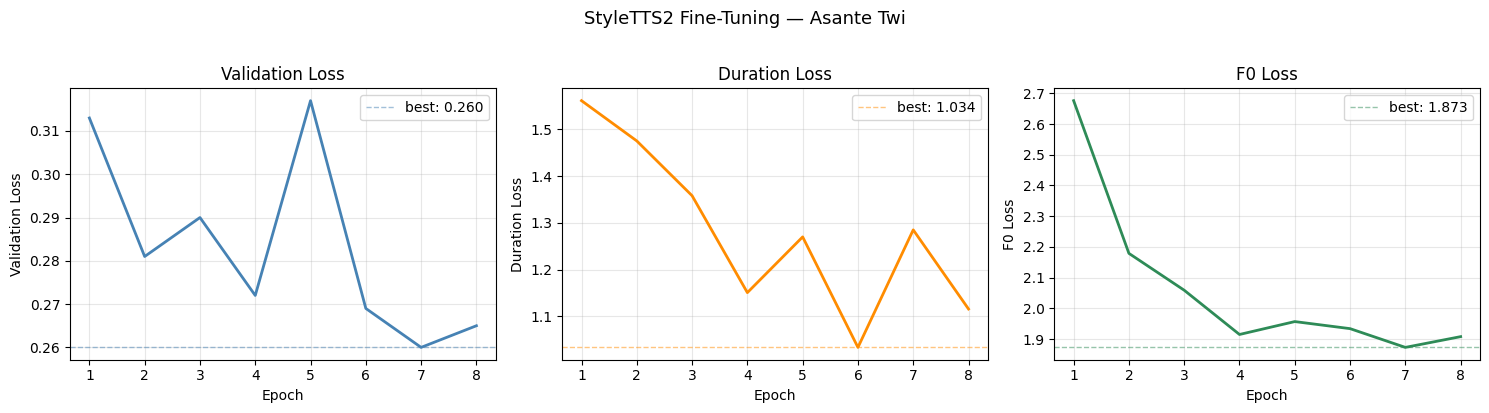

In [ ]:
import re, matplotlib.pyplot as plt

log_file = "/content/drive/MyDrive/StyleTTS2_Twi/train.log"

epochs, val_losses, dur_losses, f0_losses = [], [], [], []

with open(log_file, "r") as f:
    for i, line in enumerate(f):
        m = re.search(
            r'Validation loss:\s*([\d.]+),\s*Dur loss:\s*([\d.]+),\s*F0 loss:\s*([\d.]+)',
            line
        )
        if m:
            epochs.append(len(epochs) + 1)
            val_losses.append(float(m.group(1)))
            dur_losses.append(float(m.group(2)))
            f0_losses.append(float(m.group(3)))

print(f"Epochs found: {len(epochs)}")
print(f"Val loss  — start: {val_losses[0]:.3f}  end: {val_losses[-1]:.3f}  best: {min(val_losses):.3f} (epoch {val_losses.index(min(val_losses))+1})")
print(f"Dur loss  — start: {dur_losses[0]:.3f}  end: {dur_losses[-1]:.3f}")
print(f"F0 loss   — start: {f0_losses[0]:.3f}  end: {f0_losses[-1]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, values, label, color in zip(
    axes,
    [val_losses, dur_losses, f0_losses],
    ['Validation Loss', 'Duration Loss', 'F0 Loss'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.plot(epochs, values, linewidth=2, color=color)
    ax.axhline(min(values), linestyle='--', linewidth=1, color=color, alpha=0.5,
               label=f'best: {min(values):.3f}')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("StyleTTS2 Fine-Tuning — Asante Twi", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Test the fine-tuned model

In [ ]:
import os, sys, time
import torch, importlib

os.chdir("/content/StyleTTS2")
sys.path.insert(0, "/content/StyleTTS2")

# Patch torch.load to avoid weights_only error
if not getattr(torch.load, '_already_patched', False):
    importlib.reload(torch.serialization)
    torch.load = torch.serialization.load
    _orig = torch.load
    def _patched(*args, **kwargs):
        kwargs['weights_only'] = False
        return _orig(*args, **kwargs)
    _patched._already_patched = True
    torch.load = _patched
    print("torch.load patched ✅")
else:
    print("Already patched")

torch.load patched ✅


In [ ]:
import yaml, random, numpy as np
import torchaudio, librosa, soundfile as sf
import IPython.display as ipd
import nltk
from munch import Munch
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from models import build_model, load_ASR_models, load_F0_models
from utils  import recursive_munch
from text_utils import TextCleaner
from Utils.PLBERT.util import load_plbert
from Modules.diffusion.sampler import DiffusionSampler, ADPM2Sampler, KarrasSchedule

torch.manual_seed(0)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

textclenaer = TextCleaner()

to_mel = torchaudio.transforms.MelSpectrogram(
    n_mels=80, n_fft=2048, win_length=1200, hop_length=300)
mean, std = -4, 4

def length_to_mask(lengths):
    mask = torch.arange(lengths.max()).unsqueeze(0).expand(
        lengths.shape[0], -1).type_as(lengths)
    mask = torch.gt(mask + 1, lengths.unsqueeze(1))
    return mask

def preprocess(wave):
    wave_tensor = torch.from_numpy(wave).float()
    mel_tensor  = to_mel(wave_tensor)
    mel_tensor  = (torch.log(1e-5 + mel_tensor.unsqueeze(0)) - mean) / std
    return mel_tensor

def compute_style(path):
    wave, sr = librosa.load(path, sr=24000)
    audio, _ = librosa.effects.trim(wave, top_db=30)
    mel_tensor = preprocess(audio).to(device)
    with torch.no_grad():
        ref_s = model.style_encoder(mel_tensor.unsqueeze(1))
        ref_p = model.predictor_encoder(mel_tensor.unsqueeze(1))
    return torch.cat([ref_s, ref_p], dim=1)

Device: cuda
177


In [ ]:
from twi_g2p import TwiG2P

g2p = TwiG2P(output_format="vits")
print("twi-g2p ready")

twi-g2p ready


In [ ]:
CONFIG_PATH = "/content/StyleTTS2/Models/LibriTTS/config.yml"

if not os.path.exists(CONFIG_PATH):
    import subprocess
    subprocess.run([
        "wget", "-q",
        "https://huggingface.co/yl4579/StyleTTS2-LibriTTS/resolve/main/Models/LibriTTS/config.yml",
        "-O", CONFIG_PATH
    ])

config = yaml.safe_load(open(CONFIG_PATH))

text_aligner    = load_ASR_models(config['ASR_path'], config['ASR_config'])
pitch_extractor = load_F0_models(config['F0_path'])
plbert          = load_plbert(config['PLBERT_dir'])

model_params = recursive_munch(config['model_params'])
model        = build_model(model_params, text_aligner, pitch_extractor, plbert)
_ = [model[k].eval() for k in model]
_ = [model[k].to(device) for k in model]
print("Model built ✅")

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Model built ✅


In [ ]:
import os
from collections import OrderedDict

# ── Set your checkpoint path here ────────────────────────────────────────────
INFER_CKPT = "/content/drive/MyDrive/StyleTTS2_Twi/checkpoints/epoch_2nd_00007_small.pth"
# ─────────────────────────────────────────────────────────────────────────────

assert os.path.exists(INFER_CKPT), f"Checkpoint not found: {INFER_CKPT}"
print(f"Loading: {INFER_CKPT}  ({os.path.getsize(INFER_CKPT)/1e6:.0f} MB)")

params_whole = torch.load(INFER_CKPT, map_location='cpu', weights_only=False)
params = params_whole['net'] if 'net' in params_whole else params_whole

# Detect if checkpoint is fp16
sample_tensor = next(
    v for sd in params.values()
    for v in (sd.values() if isinstance(sd, dict) else [sd])
    if isinstance(v, torch.Tensor)
)
is_fp16 = sample_tensor.dtype == torch.float16
print(f"Checkpoint dtype: {'float16 (small)' if is_fp16 else 'float32 (full)'}")

# Load weights into model
for key in model:
    if key in params:
        try:
            model[key].load_state_dict(params[key])
        except Exception:
            sd = OrderedDict()
            for k, v in params[key].items():
                sd[k[7:] if k.startswith('module.') else k] = v
            model[key].load_state_dict(sd, strict=False)
        print(f"  ✓ {key}")

# If fp16 checkpoint, cast model back to float32 for stable inference
if is_fp16:
    for key in model:
        model[key].float()
    print("Cast fp16 → float32 ✅")

_ = [model[k].eval() for k in model]

sampler = DiffusionSampler(
    model.diffusion.diffusion,
    sampler=ADPM2Sampler(),
    sigma_schedule=KarrasSchedule(sigma_min=0.0001, sigma_max=3.0, rho=9.0),
    clamp=False
)
print(f"\nReady: {os.path.basename(INFER_CKPT)} ✅")

Loading: /content/drive/MyDrive/StyleTTS2_Twi/checkpoints/epoch_2nd_00007_small.pth  (434 MB)
Checkpoint dtype: float16 (small)
  ✓ bert
  ✓ bert_encoder
  ✓ predictor
  ✓ decoder
  ✓ text_encoder
  ✓ predictor_encoder
  ✓ style_encoder
  ✓ diffusion
  ✓ text_aligner
  ✓ pitch_extractor
  ✓ mpd
  ✓ msd
  ✓ wd
Cast fp16 → float32 ✅

Ready: epoch_2nd_00007_small.pth ✅


In [ ]:
def inference(text, ref_s, alpha=0.3, beta=0.7, diffusion_steps=5, embedding_scale=1):
    text   = text.strip()
    ps     = g2p.convert(text)          # ← twi-g2p instead of espeak
    ps     = word_tokenize(ps)
    ps     = ' '.join(ps)
    tokens = textclenaer(ps)
    tokens.insert(0, 0)
    tokens = torch.LongTensor(tokens).to(device).unsqueeze(0)

    with torch.no_grad():
        input_lengths = torch.LongTensor([tokens.shape[-1]]).to(device)
        text_mask     = length_to_mask(input_lengths).to(device)

        t_en     = model.text_encoder(tokens, input_lengths, text_mask)
        bert_dur = model.bert(tokens, attention_mask=(~text_mask).int())
        d_en     = model.bert_encoder(bert_dur).transpose(-1, -2)

        s_pred = sampler(
            noise           = torch.randn((1, 256)).unsqueeze(1).to(device),
            embedding       = bert_dur,
            embedding_scale = embedding_scale,
            features        = ref_s,
            num_steps       = diffusion_steps
        ).squeeze(1)

        s   = s_pred[:, 128:]
        ref = s_pred[:, :128]
        ref = alpha * ref + (1 - alpha) * ref_s[:, :128]
        s   = beta  * s   + (1 - beta)  * ref_s[:, 128:]

        d = model.predictor.text_encoder(d_en, s, input_lengths, text_mask)
        x, _ = model.predictor.lstm(d)
        duration = model.predictor.duration_proj(x)
        duration = torch.sigmoid(duration).sum(axis=-1)
        pred_dur = torch.round(duration.squeeze()).clamp(min=1)

        pred_aln_trg = torch.zeros(input_lengths, int(pred_dur.sum().data))
        c_frame = 0
        for i in range(pred_aln_trg.size(0)):
            pred_aln_trg[i, c_frame:c_frame + int(pred_dur[i].data)] = 1
            c_frame += int(pred_dur[i].data)

        en = (d.transpose(-1, -2) @ pred_aln_trg.unsqueeze(0).to(device))
        if model_params.decoder.type == "hifigan":
            asr_new = torch.zeros_like(en)
            asr_new[:, :, 0]  = en[:, :, 0]
            asr_new[:, :, 1:] = en[:, :, 0:-1]
            en = asr_new

        F0_pred, N_pred = model.predictor.F0Ntrain(en, s)

        asr = (t_en @ pred_aln_trg.unsqueeze(0).to(device))
        if model_params.decoder.type == "hifigan":
            asr_new = torch.zeros_like(asr)
            asr_new[:, :, 0]  = asr[:, :, 0]
            asr_new[:, :, 1:] = asr[:, :, 0:-1]
            asr = asr_new

        out = model.decoder(asr, F0_pred, N_pred, ref.squeeze().unsqueeze(0))

    return out.squeeze().cpu().numpy()[..., :-50]


# ── Synthesize ────────────────────────────────────────────────────────────────
REFERENCE_WAV = "/content/drive/MyDrive/StyleTTS2_Twi/reference_1.wav"  # any training wav
ref_s = compute_style(REFERENCE_WAV)

sentences = [
    "wo ho te sen",
    "me din de Kofi",
    "Ɔbaa a nanim teɛ nya animuonyam.",
]

for sentence in sentences:
    print(f"\n▶ {sentence}")
    print(f"  phones: {g2p.convert(sentence)}")   # so you can verify phonemization
    wav = inference(sentence, ref_s, alpha=0.3, beta=0.7, diffusion_steps=5)
    ipd.display(ipd.Audio(wav, rate=24000, normalize=False))


▶ wo ho te sen
  phones: w o̘ h o̘ t e̘ s e̘ n
w o̘ h o̘ t e̘ s e̘ n
w o̘ h o̘ t e̘ s e̘ n
w o̘ h o̘ t e̘ s e̘ n
w o̘ h o̘ t e̘ s e̘ n



▶ me din de Kofi
  phones: m e̘ d i̘ n d e̘ k o̘ f i̘
m e̘ d i̘ n d e̘ k o̘ f i̘
m e̘ d i̘ n d e̘ k o̘ f i̘
m e̘ d i̘ n d e̘ k o̘ f i̘
m e̘ d i̘ n d e̘ k o̘ f i̘
m e̘ d i̘ n d e̘ k o̘ f i̘



▶ Ɔbaa a nanim teɛ nya animuonyam.
  phones: o b a a a n a n i̘ m t e̘ e nʲ a a n i̘ m u̘ o̘ nʲ a m
o b a a a n a n i̘ m t e̘ e nʲ a a n i̘ m u̘ o̘ nʲ a m
o b a a a n a n i̘ m t e̘ e nʲ a a n i̘ m u̘ o̘ nʲ a m
o b a a a n a n i̘ m t e̘ e nʲ a a n i̘ m u̘ o̘ nʲ a m
o b a a a n a n i̘ m t e̘ e nʲ a a n i̘ m u̘ o̘ nʲ a m
o b a a a n a n i̘ m t e̘ e nʲ a a n i̘ m u̘ o̘ nʲ a m


EXPORT MODEL

In [ ]:
import torch, os

CKPT_IN  = "/content/drive/MyDrive/StyleTTS2_Twi/checkpoints/epoch_2nd_00007.pth"
CKPT_OUT = "/content/drive/MyDrive/StyleTTS2_Twi/checkpoints/epoch_2nd_00007_small.pth"

print("Loading...")
full = torch.load(CKPT_IN, map_location='cpu', weights_only=False)

# Step 1: strip optimiser states, keep only network weights
net = full['net']

# Step 2: convert all float32 tensors to float16
fp16_net = {}
for module_name, state_dict in net.items():
    fp16_net[module_name] = {
        k: v.half() if v.dtype == torch.float32 else v
        for k, v in state_dict.items()
    }

torch.save({'net': fp16_net}, CKPT_OUT)

orig_mb = os.path.getsize(CKPT_IN) / 1e6
new_mb  = os.path.getsize(CKPT_OUT) / 1e6
print(f"Original : {orig_mb:.0f} MB")
print(f"Reduced  : {new_mb:.0f} MB")
print(f"Reduction: {100*(1 - new_mb/orig_mb):.0f}%")
print(f"Saved to : {CKPT_OUT}")

Loading...
Original : 2040 MB
Reduced  : 434 MB
Reduction: 79%
Saved to : /content/drive/MyDrive/StyleTTS2_Twi/checkpoints/epoch_2nd_00007_small.pth
